In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        pass

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4070
Memoria GPU: 12.88 GB


In [2]:
BATCH_SIZE = 64
IMAGE_SIZE = 32
NUM_CHANNELS = 3
LATENT_DIM = 128
GENERATOR_FEATURES = 128
CRITIC_FEATURES = 128

NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
BETAS = (0.5, 0.9)
LAMBDA_GP = 10
CRITIC_ITERATIONS = 5

BASE_OUTPUT_DIR = "./outputs"
EXPERIMENT_NAME = "wgan_gp"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RESULTS_DIR = f"{BASE_OUTPUT_DIR}/{EXPERIMENT_NAME}_{TIMESTAMP}"
MODELS_DIR = f"{RESULTS_DIR}/models"
FIGURES_DIR = f"{RESULTS_DIR}/figures"
SAMPLES_DIR = f"{RESULTS_DIR}/samples"

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(SAMPLES_DIR, exist_ok=True)

DATA_DIR = "./data"

print(f"Épocas de entrenamiento: {NUM_EPOCHS}")
print(f"\nDirectorios de salida:")
print(f"  - Modelos:  {MODELS_DIR}")
print(f"  - Figuras:  {FIGURES_DIR}")
print(f"  - Muestras: {SAMPLES_DIR}")

Épocas de entrenamiento: 50

Directorios de salida:
  - Modelos:  ./outputs/wgan_gp_20251118_173242/models
  - Figuras:  ./outputs/wgan_gp_20251118_173242/figures
  - Muestras: ./outputs/wgan_gp_20251118_173242/samples


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, 
    train=True,
    download=True, 
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE,
    shuffle=True, 
    num_workers=0,
    drop_last=True
)

print(f"Dataset: CIFAR-10")
print(f"Tamaño del dataset: {len(train_dataset)} imágenes")
print(f"Batches por época: {len(dataloader)}")

100%|██████████| 170M/170M [00:12<00:00, 13.7MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data
Dataset: CIFAR-10
Tamaño del dataset: 50000 imágenes
Batches por época: 781


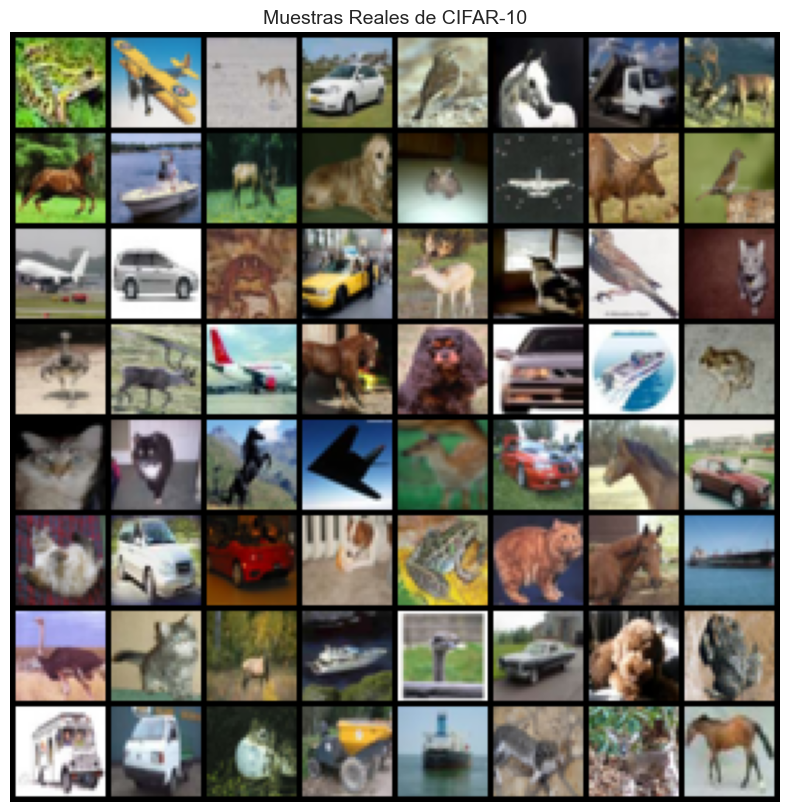

In [4]:
def show_images(images, title="Imágenes", nrow=8, save_path=None):
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.imshow(np.transpose(
        vutils.make_grid(images[:64], padding=2, normalize=True, nrow=nrow).cpu(),
        (1, 2, 0)
    ))
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

real_batch = next(iter(dataloader))[0]
show_images(real_batch, "Muestras Reales de CIFAR-10", save_path=f"{FIGURES_DIR}/real_samples.png")

In [5]:
class Critic(nn.Module):
    def __init__(self, num_channels, num_features):
        super(Critic, self).__init__()
        
        self.main = nn.Sequential(
            nn.Conv2d(num_channels, num_features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features, num_features * 2, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 2, num_features * 4, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(num_features * 4, 1, 4, 1, 0, bias=False)
        )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
    
    def forward(self, x):
        return self.main(x).view(-1)

print("Critic definido (sin BatchNorm, sin Sigmoid)")

Critic definido (sin BatchNorm, sin Sigmoid)


In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim, num_features, num_channels):
        super(Generator, self).__init__()
        self.latent_dim = latent_dim
        
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, num_features * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(num_features * 4),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features * 4, num_features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features * 2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features * 2, num_features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(num_features),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(num_features, num_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )
        
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.BatchNorm2d)):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
    
    def forward(self, z):
        return self.main(z)

print("Generator definido")

Generator definido


In [7]:
def compute_gradient_penalty(critic, real_samples, fake_samples, device):
    batch_size = real_samples.size(0)
    
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    alpha = alpha.expand_as(real_samples)
    
    interpolated = alpha * real_samples + (1 - alpha) * fake_samples
    interpolated.requires_grad_(True)
    
    critic_interpolated = critic(interpolated)
    
    gradients = autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]
    
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    gradient_penalty = ((gradient_norm - 1) ** 2).mean()
    
    return gradient_penalty

print("Función de gradient penalty definida")

Función de gradient penalty definida


In [8]:
generator = Generator(LATENT_DIM, GENERATOR_FEATURES, NUM_CHANNELS).to(device)
critic = Critic(NUM_CHANNELS, CRITIC_FEATURES).to(device)

optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE, betas=BETAS)
optimizer_C = optim.Adam(critic.parameters(), lr=LEARNING_RATE, betas=BETAS)

fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)

print("Modelos y optimizadores inicializados")
print(f"Optimizer: Adam con lr={LEARNING_RATE}, betas={BETAS}")
print(f"Lambda GP: {LAMBDA_GP}")
print(f"Critic iterations: {CRITIC_ITERATIONS}")

Modelos y optimizadores inicializados
Optimizer: Adam con lr=0.0001, betas=(0.5, 0.9)
Lambda GP: 10
Critic iterations: 5


In [9]:
c_losses = []
g_losses = []
wasserstein_distances = []
gradient_penalties = []
generated_samples = []

print(f"Iniciando entrenamiento de WGAN-GP por {NUM_EPOCHS} épocas...\n")

for epoch in range(NUM_EPOCHS):
    epoch_c_loss = 0
    epoch_g_loss = 0
    epoch_w_dist = 0
    epoch_gp = 0
    num_batches = 0
    
    for i, (real_images, _) in enumerate(dataloader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)
        
        for _ in range(CRITIC_ITERATIONS):
            optimizer_C.zero_grad()
            
            z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_images = generator(z)
            
            critic_real = critic(real_images).mean()
            critic_fake = critic(fake_images).mean()
            
            gp = compute_gradient_penalty(critic, real_images, fake_images, device)
            
            c_loss = -(critic_real - critic_fake) + LAMBDA_GP * gp
            c_loss.backward()
            optimizer_C.step()
        
        optimizer_G.zero_grad()
        
        z = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_images = generator(z)
        
        g_loss = -critic(fake_images).mean()
        g_loss.backward()
        optimizer_G.step()
        
        wasserstein_distance = critic_real.item() - critic_fake.item()
        
        epoch_c_loss += c_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_w_dist += wasserstein_distance
        epoch_gp += gp.item()
        num_batches += 1
    
    c_losses.append(epoch_c_loss / num_batches)
    g_losses.append(epoch_g_loss / num_batches)
    wasserstein_distances.append(epoch_w_dist / num_batches)
    gradient_penalties.append(epoch_gp / num_batches)
    
    with torch.no_grad():
        fake_samples = generator(fixed_noise)
        generated_samples.append(fake_samples.cpu())
    
    print(f"Época [{epoch+1}/{NUM_EPOCHS}] C_loss: {c_losses[-1]:.4f}, G_loss: {g_losses[-1]:.4f}, W-dist: {wasserstein_distances[-1]:.4f}, GP: {gradient_penalties[-1]:.4f}")

print("\nEntrenamiento completado!")

Iniciando entrenamiento de WGAN-GP por 50 épocas...

Época [1/50] C_loss: -32.3696, G_loss: -2.7767, W-dist: 44.5762, GP: 1.2207
Época [2/50] C_loss: -12.6777, G_loss: -6.4402, W-dist: 15.5501, GP: 0.2872
Época [3/50] C_loss: -6.6691, G_loss: -0.1648, W-dist: 7.5902, GP: 0.0921
Época [4/50] C_loss: -5.3646, G_loss: 0.2934, W-dist: 5.9704, GP: 0.0606
Época [5/50] C_loss: -4.6382, G_loss: 0.2455, W-dist: 5.0797, GP: 0.0441
Época [6/50] C_loss: -4.1586, G_loss: 0.2858, W-dist: 4.5184, GP: 0.0360
Época [7/50] C_loss: -3.8238, G_loss: 0.2949, W-dist: 4.1394, GP: 0.0316
Época [8/50] C_loss: -3.6409, G_loss: 0.3464, W-dist: 3.9331, GP: 0.0292
Época [9/50] C_loss: -3.4987, G_loss: 0.2595, W-dist: 3.7682, GP: 0.0270
Época [10/50] C_loss: -3.3228, G_loss: 0.3145, W-dist: 3.5651, GP: 0.0242
Época [11/50] C_loss: -3.1950, G_loss: 0.2358, W-dist: 3.4235, GP: 0.0228
Época [12/50] C_loss: -3.1283, G_loss: 0.1753, W-dist: 3.3420, GP: 0.0214
Época [13/50] C_loss: -3.0129, G_loss: 0.2790, W-dist: 3.2126

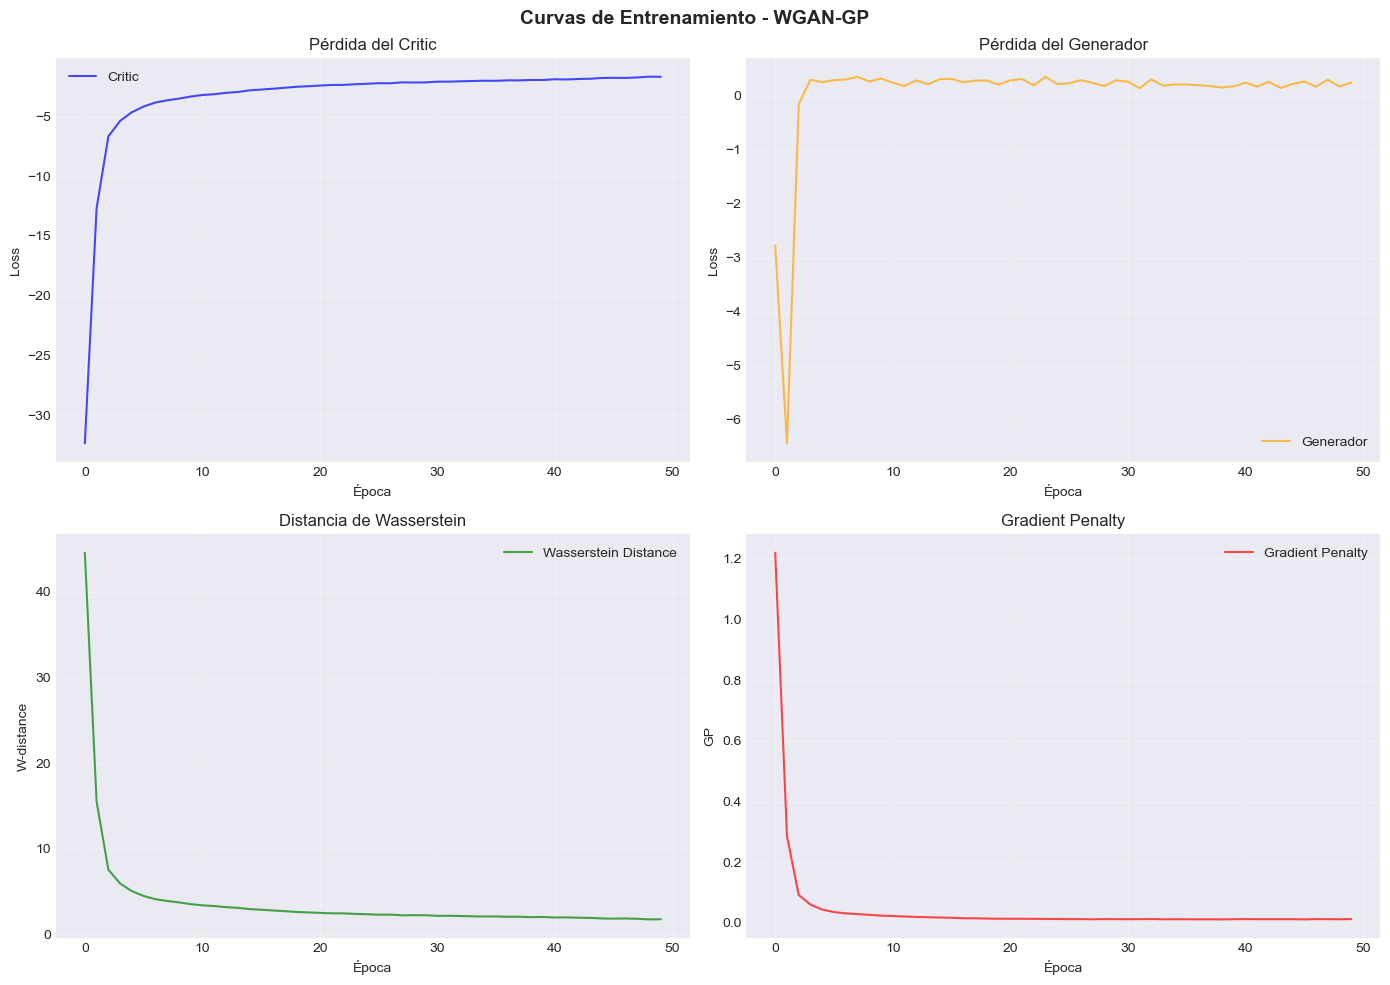

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(c_losses, label='Critic', alpha=0.7, color='blue')
axes[0, 0].set_title('Pérdida del Critic', fontsize=12)
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(g_losses, label='Generador', alpha=0.7, color='orange')
axes[0, 1].set_title('Pérdida del Generador', fontsize=12)
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(wasserstein_distances, label='Wasserstein Distance', alpha=0.7, color='green')
axes[1, 0].set_title('Distancia de Wasserstein', fontsize=12)
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('W-distance')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(gradient_penalties, label='Gradient Penalty', alpha=0.7, color='red')
axes[1, 1].set_title('Gradient Penalty', fontsize=12)
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('GP')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Curvas de Entrenamiento - WGAN-GP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

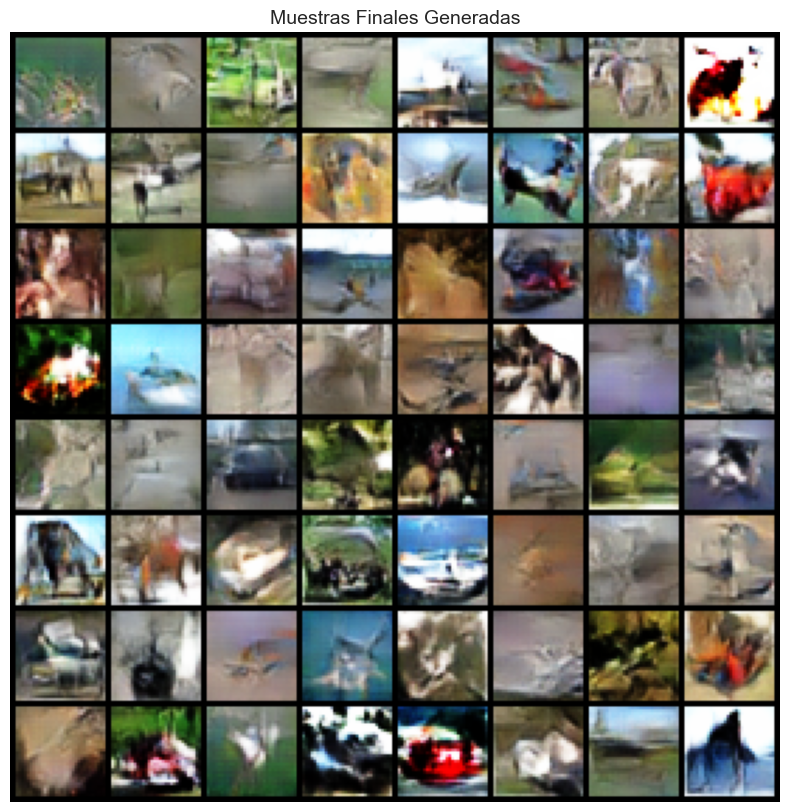

In [11]:
show_images(generated_samples[-1], "Muestras Finales Generadas", save_path=f"{FIGURES_DIR}/final_samples.png")

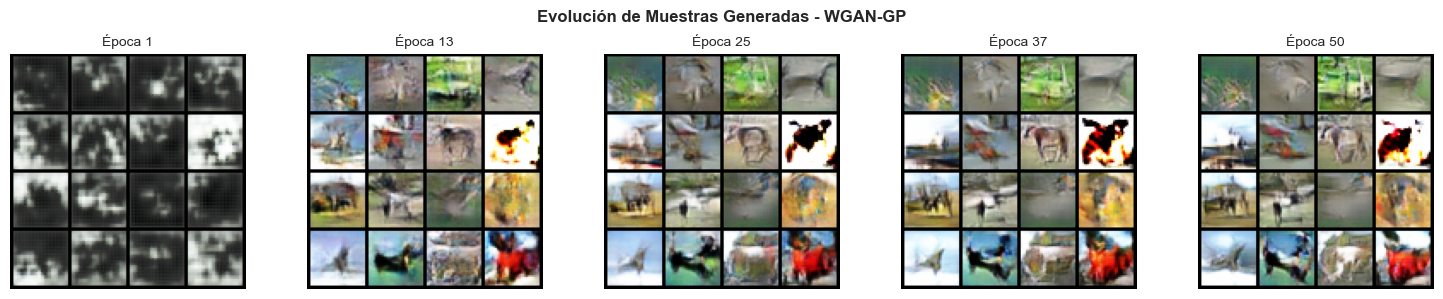

In [12]:
num_samples = 5
total_epochs = len(generated_samples)
indices = np.linspace(0, total_epochs-1, num_samples, dtype=int)

fig, axes = plt.subplots(1, num_samples, figsize=(3*num_samples, 3))

for idx, epoch_idx in enumerate(indices):
    samples = generated_samples[epoch_idx][:16]
    grid = vutils.make_grid(samples, padding=2, normalize=True, nrow=4)
    axes[idx].imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    axes[idx].set_title(f'Época {epoch_idx+1}', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('Evolución de Muestras Generadas - WGAN-GP', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sample_evolution.png", dpi=150, bbox_inches='tight')
plt.show()

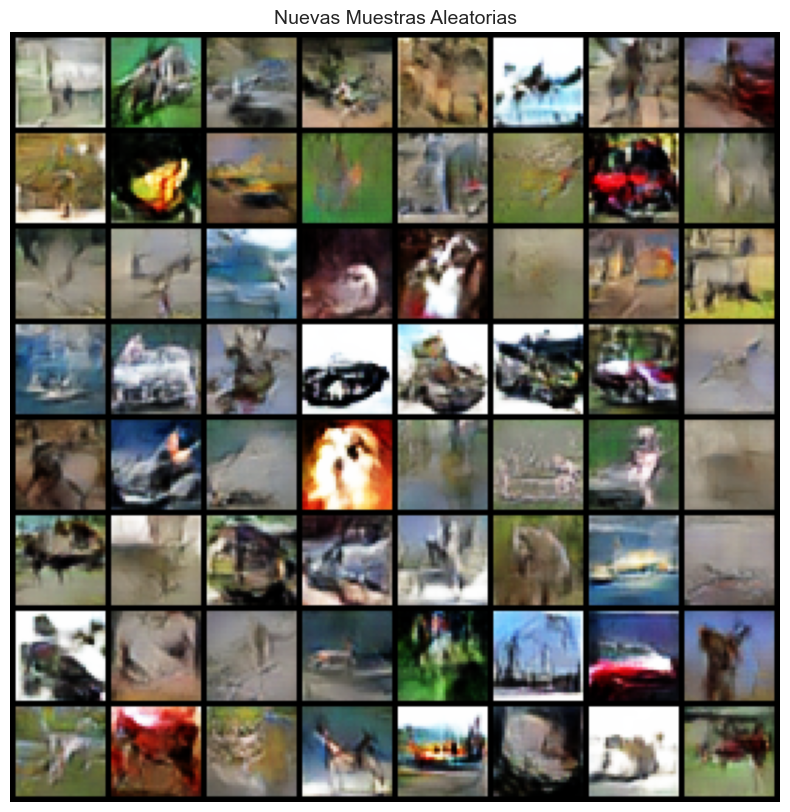

In [13]:
with torch.no_grad():
    z = torch.randn(64, LATENT_DIM, 1, 1, device=device)
    new_samples = generator(z)
    show_images(new_samples, "Nuevas Muestras Aleatorias", save_path=f"{FIGURES_DIR}/random_samples.png")

In [14]:
torch.save(generator.state_dict(), f'{MODELS_DIR}/generator.pth')
torch.save(critic.state_dict(), f'{MODELS_DIR}/critic.pth')

print("Modelos guardados exitosamente:")
print(f"  ✓ Generador: {MODELS_DIR}/generator.pth")
print(f"  ✓ Critic: {MODELS_DIR}/critic.pth")

Modelos guardados exitosamente:
  ✓ Generador: ./outputs/wgan_gp_20251118_173242/models/generator.pth
  ✓ Critic: ./outputs/wgan_gp_20251118_173242/models/critic.pth


In [15]:
print("\n" + "="*70)
print("RESUMEN DE ENTRENAMIENTO - WGAN-GP")
print("="*70)

print(f"\nPérdida final del Critic: {c_losses[-1]:.4f}")
print(f"Pérdida final del Generador: {g_losses[-1]:.4f}")
print(f"Wasserstein distance final: {wasserstein_distances[-1]:.4f}")
print(f"Gradient penalty final: {gradient_penalties[-1]:.4f}")

print(f"\nWasserstein distance inicial: {wasserstein_distances[0]:.4f}")
print(f"Wasserstein distance final: {wasserstein_distances[-1]:.4f}")
print(f"Mejora: {wasserstein_distances[0] - wasserstein_distances[-1]:.4f}")

print(f"\nGradient penalty promedio: {np.mean(gradient_penalties):.4f}")
print(f"Gradient penalty std: {np.std(gradient_penalties):.4f}")

print(f"\nTotal de épocas: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Lambda GP: {LAMBDA_GP}")
print(f"Critic iterations: {CRITIC_ITERATIONS}")

print("\n" + "="*70)


RESUMEN DE ENTRENAMIENTO - WGAN-GP

Pérdida final del Critic: -1.6704
Pérdida final del Generador: 0.2412
Wasserstein distance final: 1.7992
Gradient penalty final: 0.0129

Wasserstein distance inicial: 44.5762
Wasserstein distance final: 1.7992
Mejora: 42.7770

Gradient penalty promedio: 0.0482
Gradient penalty std: 0.1722

Total de épocas: 50
Learning rate: 0.0001
Lambda GP: 10
Critic iterations: 5

